In [13]:
!pip install wordcloud

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set(style="whitegrid")

In [15]:
df = pd.read_csv("../data/spam.csv", encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
print(df.info())
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label
ham     4825
spam     747
Name: count, dtype: int64


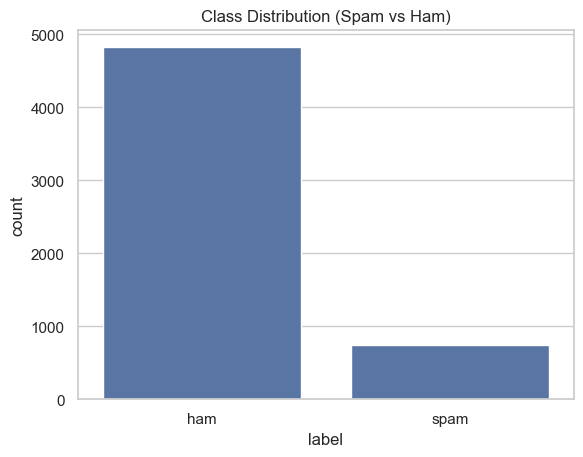

In [17]:
sns.countplot(x='label', data=df)
plt.title("Class Distribution (Spam vs Ham)")
plt.savefig("../outputs/plots/class_distribution.png")
plt.show()

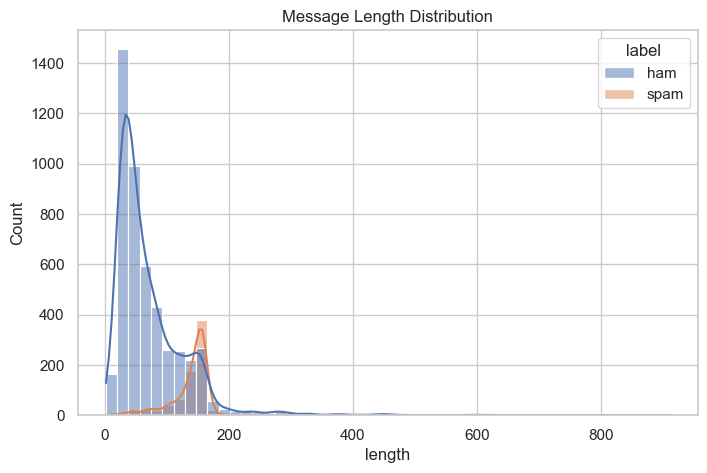

In [18]:
df['length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True)
plt.title("Message Length Distribution")
plt.savefig("../outputs/plots/message_length.png")
plt.show()

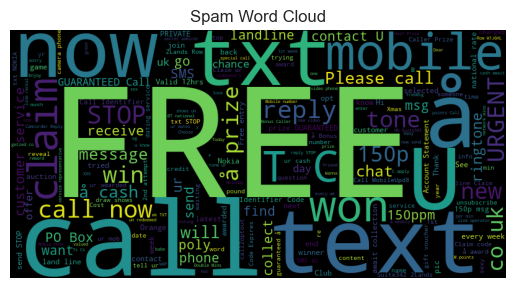

In [19]:
spam_words = " ".join(df[df['label'] == 'spam']['message'])

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(spam_words)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Spam Word Cloud")
plt.savefig("../outputs/plots/spam_wordcloud.png")
plt.show()

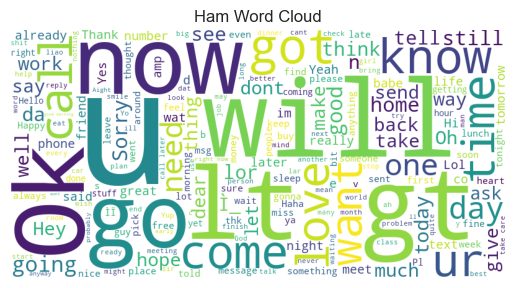

In [20]:
ham_words = " ".join(df[df['label'] == 'ham']['message'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham_words)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Ham Word Cloud")
plt.savefig("../outputs/plots/ham_wordcloud.png")
plt.show()

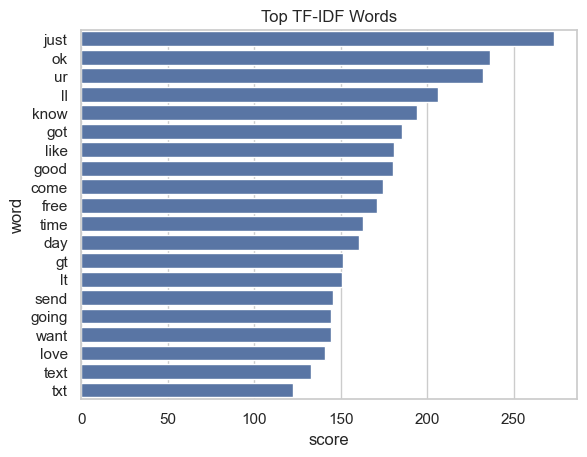

In [21]:
tfidf = TfidfVectorizer(max_features=20, stop_words='english')
X = tfidf.fit_transform(df['message'])

words = tfidf.get_feature_names_out()
scores = X.sum(axis=0).A1

tfidf_df = pd.DataFrame({'word': words, 'score': scores})
tfidf_df = tfidf_df.sort_values(by='score', ascending=False)

sns.barplot(x='score', y='word', data=tfidf_df)
plt.title("Top TF-IDF Words")
plt.savefig("../outputs/plots/tfidf_words.png")
plt.show()

### 📊 Key Insights

- Dataset is imbalanced (more ham than spam)
- Spam messages tend to be longer
- Common spam words include: "free", "win", "offer"
- TF-IDF highlights important words rather than frequent ones
- Text preprocessing is essential before model training